In [58]:
# Clear all variables and import libraries
%reset -f
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
from scipy.interpolate import griddata
import re
import os
from math import ceil

In [59]:
# Configuration - Update these paths to your data folders
folder_name = '30_Re_500_layers'  # Output folder for plots
sim_folder = r'../30/sim/30_Re_500/Pos3_transformed_f250'
#'../irregular/sim/irregular_0.07_extended/Pos3_transformed_all'
#'../30/SIM_Data/30_Degree_Old_simulation_results/30_Degree_Old_simulation_results/CSV_files/Sim_csv_files/pos3_transformed'
output_dir = '../Plots/'+ folder_name

z_velocity_offset = 0.0
distance_step = 0.002  # 2 mm steps
max_distance = 0.009   # Up to 9 mm from bottom

# Plot parameters
n_grid = 500      # Grid resolution for contour
n_arrows = 14    # Number of arrows for streamplot

# --- Layer flipping ---------------------------------------------------------
# Master switch: set to 1 to mirror selected layers along the X-axis, 0 to disable.
FLIP_LAYERS = 0
# Enter the LAYER NUMBERS to flip (just the integers, e.g. 12 means "L12").
# Edit this list freely - the flip cell is idempotent, so re-running is safe.
FLIP_LAYER_NUMBERS = [3, 10, 11, 12, 18]

# Contour figure: number of columns to split the layer stack into (2 for paper).
N_CONTOUR_COLS = 1

# If 1, plots use the common (overlapping) X-range shared by all layers;
# if 0, they use the global (union) X-range.
TRIM_TO_COMMON_X_RANGE = 1

In [60]:
# Simulation data column names
sim_x_col = 'Points_0'
sim_z_col = 'Points_2'
sim_u_col = 'av_u_0'
sim_w_col = 'av_u_2'
# sim_x_col = 'x'
# sim_z_col = 'z'
# sim_u_col = 'Vel_u'
# sim_w_col = 'Vel_w'

In [61]:
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Load all CSV files
sim_files = glob.glob(f"{sim_folder}/*.csv")

sim_files.sort()
sim_files = sim_files[::-1]  # Reverse to match layer order

print(f"Found {len(sim_files)} simulation files")

# Load dataframes
sim_dataframes = [pd.read_csv(file) for file in sim_files]

# Extract file names for layer labels
sim_file_names = [os.path.basename(file) for file in sim_files]

print(f"\nSimulation files: {sim_file_names}")

# Auto-detect position and Reynolds number from first filename
test_filename = sim_file_names[0]

# Extract position
pos_match = re.search(r'Pos(\d+)', test_filename)
if pos_match:
    position = int(pos_match.group(1))
    print(f"Automatically detected Position: {position}")
else:
    position = 1  # Default fallback
    print(f"Could not detect position from filename, using default: {position}")

# Extract Reynolds number
re_match = re.search(r'Re(\d+)', test_filename)
if re_match:
    Re_p = int(re_match.group(1))
    print(f"Automatically detected Re_p: {Re_p}")
else:
    Re_p = 0  # Default fallback
    print(f"Could not detect Re_p from filename, using default: {Re_p}")



Found 4 simulation files

Simulation files: ['SIM_L17_Pos3_F250_B0001_T_transformed.csv', 'SIM_L16_Pos3_F250_B0001_T_transformed.csv', 'SIM_L14_Pos3_F250_B0001_T_transformed.csv', 'SIM_L13_Pos3_F250_B0001_T_transformed.csv']
Automatically detected Position: 3
Could not detect Re_p from filename, using default: 0


In [62]:
print(f"Grid resolution: {n_grid}")
print(f"Streamplot arrows: {n_arrows}")

# Apply z_velocity_offset to simulation data and calculate velocity magnitudes
print("Applying z_velocity_offset to simulation data...")
for df_sim in sim_dataframes:
    df_sim[sim_w_col] = df_sim[sim_w_col] + z_velocity_offset

print("Calculating velocity magnitudes...")

all_vel_mag_values = []

# Calculate for simulation data (with offset already applied)
for df_sim in sim_dataframes:
    df_sim['vel_magnitude'] = np.sqrt(df_sim[sim_u_col]**2 + df_sim[sim_w_col]**2)
    all_vel_mag_values.extend(df_sim['vel_magnitude'].values)

# Calculate common colorbar limits from all data
all_vel_mag_values = np.array(all_vel_mag_values)
all_vel_mag_values = all_vel_mag_values[np.isfinite(all_vel_mag_values)]  # Remove NaN and inf

common_vmin = all_vel_mag_values.min()
common_vmax = all_vel_mag_values.max()

print(f"\nCalculated velocity magnitude range from all data:")
print(f"  Min: {common_vmin:.6f} m/s")
print(f"  Max: {common_vmax:.6f} m/s")

levels = np.linspace(common_vmin, common_vmax, 50)

# Determine z-range for line plots
z_min_sim = float(min(df[sim_z_col].min() for df in sim_dataframes))
z_max_sim = float(max(df[sim_z_col].max() for df in sim_dataframes))

Grid resolution: 500
Streamplot arrows: 14
Applying z_velocity_offset to simulation data...
Calculating velocity magnitudes...

Calculated velocity magnitude range from all data:
  Min: 0.003676 m/s
  Max: 3.420573 m/s


In [63]:
# Compute min/max x per file and highlight overall min/max
x_mins, x_maxs, files = [], [], []

for df, fname in zip(sim_dataframes, sim_file_names):
    xm = df[sim_x_col].min()
    xM = df[sim_x_col].max()
    x_mins.append(xm)
    x_maxs.append(xM)
    files.append(fname)

summary_x = pd.DataFrame({'file': files, 'x_min': x_mins, 'x_max': x_maxs})
print(summary_x.to_string(index=False))

overall_min = min(x_mins)
overall_max = max(x_maxs)
min_idx = x_mins.index(overall_min)
max_idx = x_maxs.index(overall_max)

print(f"\nOverall MIN x: {overall_min:.6f}  (file: {sim_file_names[min_idx]})")
print(sim_dataframes[min_idx].loc[sim_dataframes[min_idx][sim_x_col].idxmin(), [sim_x_col, sim_z_col, 'vel_magnitude']])

print(f"\nOverall MAX x: {overall_max:.6f}  (file: {sim_file_names[max_idx]})")
print(sim_dataframes[max_idx].loc[sim_dataframes[max_idx][sim_x_col].idxmax(), [sim_x_col, sim_z_col, 'vel_magnitude']])

                                     file     x_min    x_max
SIM_L17_Pos3_F250_B0001_T_transformed.csv -0.029791 0.029792
SIM_L16_Pos3_F250_B0001_T_transformed.csv -0.029791 0.029792
SIM_L14_Pos3_F250_B0001_T_transformed.csv -0.029792 0.029791
SIM_L13_Pos3_F250_B0001_T_transformed.csv -0.029792 0.029791

Overall MIN x: -0.029792  (file: SIM_L14_Pos3_F250_B0001_T_transformed.csv)
Points_0        -0.029792
Points_2         0.130145
vel_magnitude    0.721542
Name: 91, dtype: float64

Overall MAX x: 0.029792  (file: SIM_L16_Pos3_F250_B0001_T_transformed.csv)
Points_0         0.029792
Points_2         0.150245
vel_magnitude    0.378742
Name: 1, dtype: float64


In [64]:
# FLIP SELECTED LAYERS ALONG THE X-AXIS
# ============================================================
# Which layers are flipped is controlled by FLIP_LAYER_NUMBERS in the config cell.
# This cell is IDEMPOTENT: each dataframe is tagged once it has been flipped
# (df.attrs['x_flipped']), so re-running the cell will NOT double-flip / undo.
# Re-running the data-load cell creates fresh dataframes, which clears the tag.

if FLIP_LAYERS:
    layers_to_flip = {f"L{int(n):02d}" for n in FLIP_LAYER_NUMBERS}

    print("=" * 80)
    print(f"FLIPPING LAYERS ALONG X-AXIS: {', '.join(sorted(layers_to_flip))}")
    print("=" * 80)

    flipped_now = []
    already_flipped = []
    not_found = set(layers_to_flip)

    for df, filename in zip(sim_dataframes, sim_file_names):
        layer_match = re.search(r'L(\d{2})', filename)
        if not layer_match:
            continue
        layer_id = f"L{layer_match.group(1)}"
        if layer_id not in layers_to_flip:
            continue

        not_found.discard(layer_id)

        # Idempotency guard - skip dataframes that were already flipped
        if df.attrs.get('x_flipped', False):
            already_flipped.append(layer_id)
            print(f"• {layer_id} already flipped — skipped (re-run safe)")
            continue

        x_min_before, x_max_before = df[sim_x_col].min(), df[sim_x_col].max()
        u_min_before, u_max_before = df[sim_u_col].min(), df[sim_u_col].max()

        # Mirror x-coordinate and x-velocity component
        df[sim_x_col] = -df[sim_x_col]
        df[sim_u_col] = -df[sim_u_col]
        # Magnitude is unchanged by a sign flip, but recompute to stay consistent
        df['vel_magnitude'] = np.sqrt(df[sim_u_col] ** 2 + df[sim_w_col] ** 2)
        df.attrs['x_flipped'] = True

        print(f"✓ Flipped SIMULATION {layer_id}")
        print(f"  X range:   [{x_min_before:.6f}, {x_max_before:.6f}] → "
              f"[{df[sim_x_col].min():.6f}, {df[sim_x_col].max():.6f}]")
        print(f"  Vel_u range: [{u_min_before:.6f}, {u_max_before:.6f}] → "
              f"[{-u_max_before:.6f}, {-u_min_before:.6f}]")
        flipped_now.append(layer_id)

    print("\n" + "=" * 80)
    print(f"Flipping complete! Newly flipped this run: {len(flipped_now)} layer(s).")
    if flipped_now:
        print(f"  Newly flipped: {', '.join(flipped_now)}")
    if already_flipped:
        print(f"  Already flipped (skipped): {', '.join(already_flipped)}")
    if not_found:
        print(f"  ⚠ Requested but not found in loaded files: {', '.join(sorted(not_found))}")
    print("=" * 80 + "\n")
else:
    print("\n" + "-" * 80)
    print("Layer flipping is DISABLED")
    print("Set FLIP_LAYERS = 1 and list layer numbers in FLIP_LAYER_NUMBERS to enable.")
    print("-" * 80 + "\n")


--------------------------------------------------------------------------------
Layer flipping is DISABLED
Set FLIP_LAYERS = 1 and list layer numbers in FLIP_LAYER_NUMBERS to enable.
--------------------------------------------------------------------------------



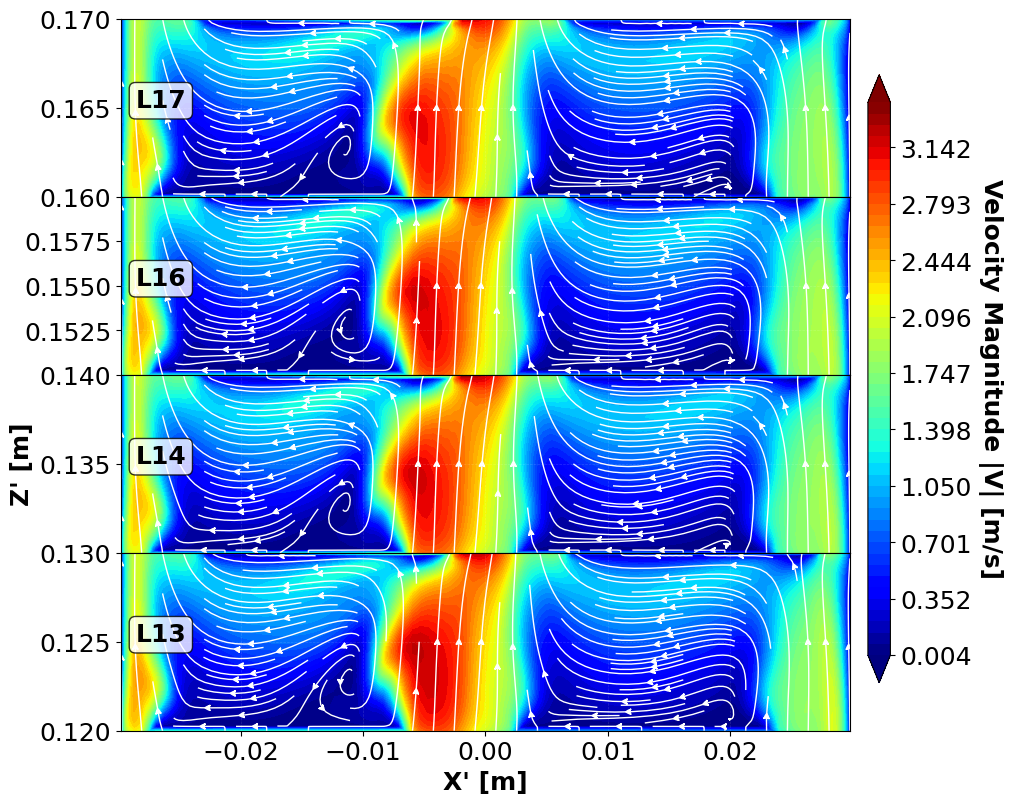

In [65]:
# Simulation contour fields - 2-COLUMN layout for the paper
# Left column  = lower layers (physical bottom at the bottom-left)
# Right column = upper layers (physical top at the top-right)
# Each column is stacked continuously (no vertical gaps between its layers).

n_layers = len(sim_dataframes)
n_cols = N_CONTOUR_COLS
n_rows = ceil(n_layers / n_cols)

# Shared X-range for every panel (common overlap or global union)
if TRIM_TO_COMMON_X_RANGE:
    x_min_global = max(df[sim_x_col].min() for df in sim_dataframes)
    x_max_global = min(df[sim_x_col].max() for df in sim_dataframes)
else:
    x_min_global = min(df[sim_x_col].min() for df in sim_dataframes)
    x_max_global = max(df[sim_x_col].max() for df in sim_dataframes)

# sim_dataframes is ordered top->bottom (L17 .. L03); reverse to bottom->top.
order_bottom_to_top = list(range(n_layers))[::-1]
rows_per_col = ceil(n_layers / n_cols)
# Split into columns: column 0 = lowest layers, last column = highest layers
columns = [order_bottom_to_top[c * rows_per_col:(c + 1) * rows_per_col]
           for c in range(n_cols)]

fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols,
    figsize=(9 * n_cols, 2 * n_rows),
    squeeze=False
)

contour_sim = None  # keep last contour handle for the shared colorbar

for c, col_indices in enumerate(columns):
    n_in_col = len(col_indices)
    # Hide unused (top) rows so each column is anchored at the bottom row
    for row in range(n_rows - n_in_col):
        axes[row][c].set_visible(False)

    for pos, layer_idx in enumerate(col_indices):  # pos 0 = lowest layer in column
        row = n_rows - 1 - pos                      # lowest layer at the bottom row
        ax_sim = axes[row][c]
        df_sim = sim_dataframes[layer_idx]

        sim_match = re.search(r'L(\d{2})', sim_file_names[layer_idx])
        layer_label = f"L{sim_match.group(1)}" if sim_match else f"Layer {layer_idx + 1}"

        x_sim = df_sim[sim_x_col].values
        z_sim = df_sim[sim_z_col].values
        u_sim = df_sim[sim_u_col].values
        w_sim = df_sim[sim_w_col].values
        vel_mag_sim = df_sim['vel_magnitude'].values

        xi = np.linspace(x_min_global, x_max_global, n_grid)
        zi = np.linspace(z_sim.min(), z_sim.max(), n_grid)
        Xi, Zi = np.meshgrid(xi, zi)

        points = np.column_stack((x_sim, z_sim))
        Ui = griddata(points, u_sim, (Xi, Zi), method='linear', fill_value=0)
        Wi = griddata(points, w_sim, (Xi, Zi), method='linear', fill_value=0)
        Vmag = griddata(points, vel_mag_sim, (Xi, Zi), method='linear', fill_value=0)

        mag = np.sqrt(Ui ** 2 + Wi ** 2)
        Ui_norm = np.zeros_like(Ui)
        Wi_norm = np.zeros_like(Wi)
        mask = mag > 1e-6
        Ui_norm[mask] = Ui[mask] / mag[mask]
        Wi_norm[mask] = Wi[mask] / mag[mask]

        contour_sim = ax_sim.contourf(
            Xi, Zi, Vmag,
            levels=levels, cmap='jet',
            vmin=common_vmin, vmax=common_vmax, extend='both'
        )
        ax_sim.streamplot(
            Xi, Zi, Ui_norm, Wi_norm,
            density=1.2, color='white',
            linewidth=1.0, arrowsize=0.9, arrowstyle='fancy'
        )

        ax_sim.set_ylim(z_sim.min(), z_sim.max())
        ax_sim.set_xlim(x_min_global, x_max_global)
        ax_sim.margins(x=0, y=0)
        ax_sim.grid(True, linestyle='--', alpha=0.15, color='white', linewidth=0.5)

        # Only the bottom panel of each column gets x ticks/labels
        if row == n_rows - 1:
            ax_sim.tick_params(axis='x', bottom=True, labelbottom=True, labelsize=18)
            ax_sim.set_xlabel("X' [m]", fontsize=18, fontweight='bold')
        else:
            ax_sim.tick_params(axis='x', bottom=False, labelbottom=False)

        ax_sim.tick_params(axis='y', left=True, labelleft=True, labelsize=18)

        ax_sim.annotate(
            layer_label, xy=(0.02, 0.50), xycoords='axes fraction',
            fontsize=18, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", alpha=0.8)
        )

# Shared Y label (one per column, on the vertically-central visible panel)
for c in range(1):
    axes[n_rows // 2][c].set_ylabel("Z' [m]", fontsize=18, fontweight='bold')

# Layout - no vertical gaps within columns, small gap between columns
fig.subplots_adjust(
    left=0.07, right=0.88, top=0.95, bottom=0.06,
    hspace=0.0, wspace=0.16
)

# Shared colorbar on the far right
cbar_ax = fig.add_axes([0.90, 0.12, 0.025, 0.76])  # (left, bottom, width, height)
cbar = fig.colorbar(contour_sim, cax=cbar_ax)
cbar.set_label(
    'Velocity Magnitude |V| [m/s]',
    rotation=270, labelpad=22, fontsize=18, fontweight='bold'
)
cbar.ax.tick_params(labelsize=18)

#fig.suptitle(
#    f'Simulation Velocity Fields - Re$_p$ = {Re_p}, Position {position}',
#    fontsize=20, fontweight='bold', y=0.985
#)

plt.savefig(f'{output_dir}/Parallel_Sim_Velocity_Fields_Pos{position}_Re{Re_p}_2col.png',
            dpi=300, bbox_inches='tight')
plt.show()


Plotting at distances from bottom (mm): [2.0, 4.0, 6.0, 8.0]
Total number of plots: 4
Global X-axis range: [-0.029792, 0.029792] m

Saved: ../Plots/30_Re_500_layers/Sim_Line_Profiles_from_Bottom_Pos3_Re0.png


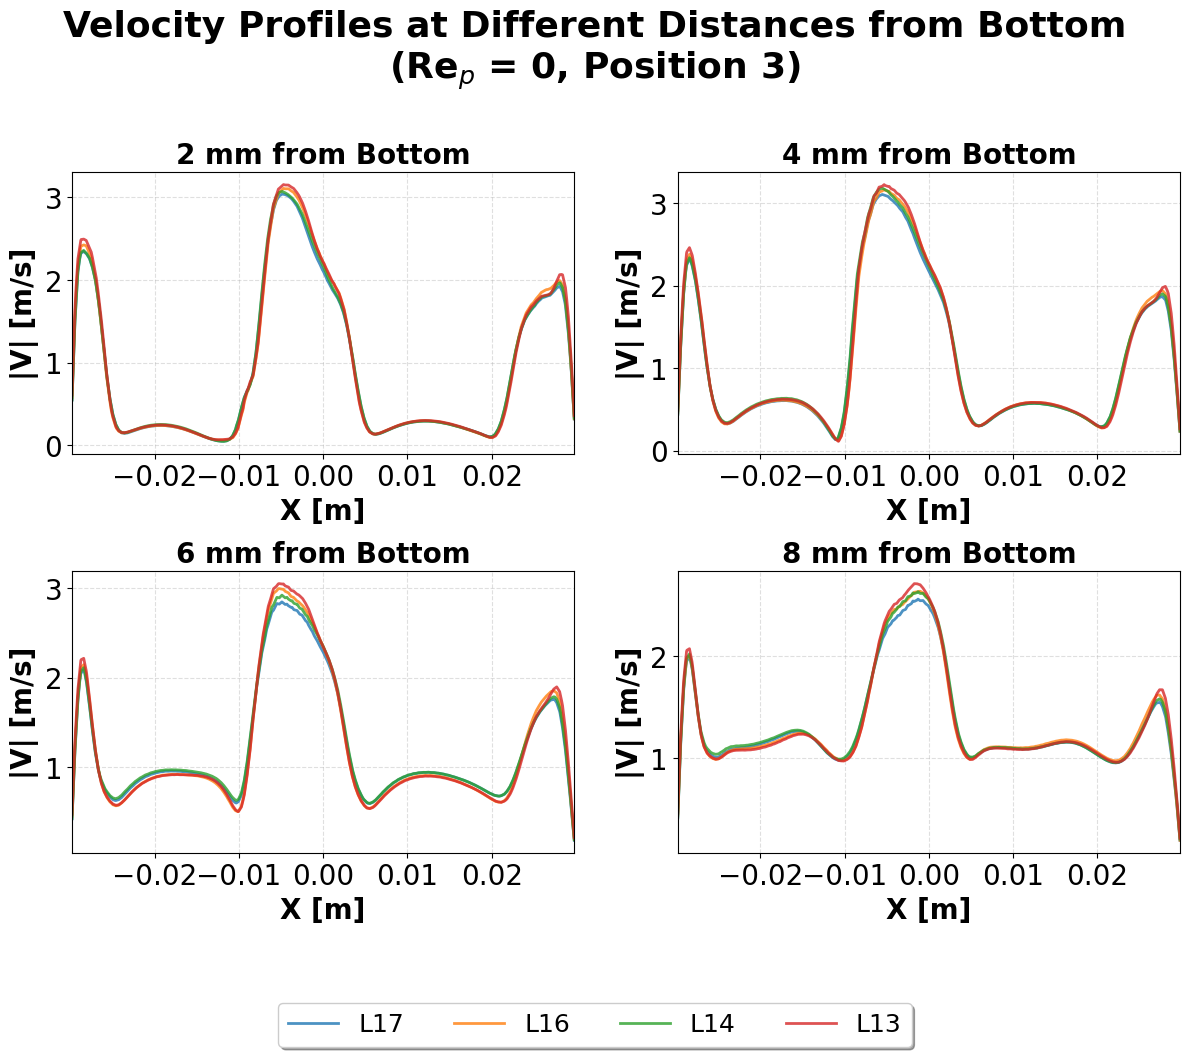

In [66]:
# Line plots at specific distances from bottom of layer
# Show all simulation layers

distances_from_bottom = np.arange(distance_step, max_distance + 1e-12, distance_step)

print(f"\nPlotting at distances from bottom (mm): {[d*1000 for d in distances_from_bottom]}")
print(f"Total number of plots: {len(distances_from_bottom)}")

# Calculate global x-limits from simulation data for consistent x-axis across subplots
x_min_global = min(df[sim_x_col].min() for df in sim_dataframes)
x_max_global = max(df[sim_x_col].max() for df in sim_dataframes)

print(f"Global X-axis range: [{x_min_global:.6f}, {x_max_global:.6f}] m")

# Determine subplot layout
n_plots = len(distances_from_bottom)
if n_plots <= 4:
    n_rows, n_cols = 2, 2
elif n_plots <= 6:
    n_rows, n_cols = 2, 3
elif n_plots <= 9:
    n_rows, n_cols = 3, 3
else:
    n_rows, n_cols = 3, 4

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

# Process each distance from bottom
for idx, distance in enumerate(distances_from_bottom):
    deci = 5  # Precision for filtering
    ax = axes[idx]
    
    # Plot all SIMULATION layers
    for i, df_sim in enumerate(sim_dataframes):
        # Calculate z-position for this layer (distance from its bottom)
        z_min_layer = df_sim[sim_z_col].min()
        z_target = z_min_layer + distance
        
        # Check if this distance exists in this layer
        if z_target <= df_sim[sim_z_col].max():
            # Find closest z-value in simulation data
            closest_z_sim = df_sim[sim_z_col].iloc[(df_sim[sim_z_col] - z_target).abs().argsort()[:1]].iloc[0]
            
            # Filter data at this Z-height
            df_sim_filtered = df_sim[abs(df_sim[sim_z_col] - closest_z_sim) < 10**(-deci)]
            
            if len(df_sim_filtered) > 0:
                df_sim_filtered = df_sim_filtered.sort_values(sim_x_col)
                
                # Extract layer label from filename
                sim_match = re.search(r'L(\d{2})', sim_file_names[i])
                layer_label = f"L{sim_match.group(1)}" if sim_match else f"Layer {i+1}"
                
                # Plot simulation layer
                ax.plot(df_sim_filtered[sim_x_col], df_sim_filtered['vel_magnitude'], 
                       label=layer_label, linestyle='-', linewidth=2.0, alpha=0.8)
    
    # Configure subplot with consistent x-limits
    ax.set_xlim(x_min_global, x_max_global)
    ax.set_xlabel('X [m]', fontsize=20, fontweight='bold')
    ax.set_ylabel('|V| [m/s]', fontsize=20, fontweight='bold')
    ax.set_title(f'{distance*1000:.0f} mm from Bottom', fontsize=20, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.8)
    ax.tick_params(axis='both', labelsize=20)

# Hide unused subplots
for i in range(n_plots, len(axes)):
    axes[i].set_visible(False)

# Create single legend at the bottom for all subplots
handles, labels = axes[0].get_legend_handles_labels()

# Place legend below all subplots
ncol = ceil(len(labels))
fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.07),
           ncol=6,
           fontsize=18,
           frameon=True,
           fancybox=True,
           shadow=True)

# Add overall title
fig.suptitle(f'Velocity Profiles at Different Distances from Bottom\n(Re$_p$ = {Re_p}, Position {position})', 
            fontsize=26, fontweight='bold', y=0.98)

# Adjust layout
plt.tight_layout(rect=[0, 0.05, 1, 0.96])

# Save plot
plot_filename = f'{output_dir}/Sim_Line_Profiles_from_Bottom_Pos{position}_Re{Re_p}.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"\nSaved: {plot_filename}")

plt.show()


In [67]:
# Calculate height from bottom for each simulation layer
sim_heights_m = []
sim_mean_vels = []
sim_layer_labels = []

# Create summary DataFrame showing mean velocities per layer
print("SUMMARY: Mean Velocity Magnitude Per Layer")

layer_names = []
layer_mean_vel_sim = []
layer_mean_u_sim = []
layer_mean_w_sim = []

n_layers = len(sim_dataframes)

for i in range(n_layers):
    df_sim = sim_dataframes[i]
    
    # Extract layer label
    sim_match = re.search(r'L(\d{2})', sim_file_names[i])
    layer_name = f"L{sim_match.group(1)}" if sim_match else f"Layer {i+1}"
    
    layer_names.append(layer_name)
    layer_mean_vel_sim.append(df_sim['vel_magnitude'].mean())
    layer_mean_u_sim.append(df_sim[sim_u_col].mean())
    layer_mean_w_sim.append(df_sim[sim_w_col].mean())

# Create summary DataFrame
summary_df = pd.DataFrame({
    'Layer': layer_names,
    'Mean_|V|_[m/s]': layer_mean_vel_sim,
    'Mean_u_[m/s]': layer_mean_u_sim,
    'Mean_w_[m/s]': layer_mean_w_sim
})

# Format and display
pd.options.display.float_format = '{:.6f}'.format
print("\n" + summary_df.to_string(index=False))

# Calculate statistics
avg_mean_vel = summary_df['Mean_|V|_[m/s]'].mean()
std_mean_vel = summary_df['Mean_|V|_[m/s]'].std()
overall_mean = summary_df['Mean_|V|_[m/s]'].mean()

print(f"\nAverage Mean Velocity [m/s]: {avg_mean_vel:.6f}")
print(f"Standard Deviation [m/s]: {std_mean_vel:.6f}")
print(f"Overall Mean Velocity [m/s]: {overall_mean:.6f}")
# Final summary statistics
print("OVERALL SIMULATION STATISTICS")
# Collect all velocity data
all_sim_u = []
all_sim_w = []
all_sim_mag = []

for df_sim in sim_dataframes:
    all_sim_u.extend(df_sim[sim_u_col].values)
    all_sim_w.extend(df_sim[sim_w_col].values)
    all_sim_mag.extend(df_sim['vel_magnitude'].values)

# Convert to arrays
all_sim_u = np.array(all_sim_u)
all_sim_w = np.array(all_sim_w)
all_sim_mag = np.array(all_sim_mag)

# Calculate statistics
stats_df = pd.DataFrame({
    'Component': ['u (X-velocity)', 'w (Z-velocity)', '|V| (Magnitude)'],
    'Min [m/s]': [all_sim_u.min(), all_sim_w.min(), all_sim_mag.min()],
    'Mean [m/s]': [all_sim_u.mean(), all_sim_w.mean(), all_sim_mag.mean()],
    'Max [m/s]': [all_sim_u.max(), all_sim_w.max(), all_sim_mag.max()],
    'Std Dev [m/s]': [all_sim_u.std(), all_sim_w.std(), all_sim_mag.std()]
})

pd.options.display.float_format = '{:.6f}'.format
print("\n" + stats_df.to_string(index=False))

combined_path = f'{output_dir}/simulation_summary_combined_Pos{position}_Re{Re_p}.png.csv'

with open(combined_path, 'w') as f:
    f.write("=== MEAN VELOCITY PER LAYER ===\n")
    summary_df.to_csv(f, index=False)
    f.write("\n=== OVERALL SIMULATION STATISTICS ===\n")
    stats_df.to_csv(f, index=False)

print(f"Saved combined summary to: {combined_path}")

# Reset display format
pd.reset_option('display.float_format')

SUMMARY: Mean Velocity Magnitude Per Layer

Layer  Mean_|V|_[m/s]  Mean_u_[m/s]  Mean_w_[m/s]
  L17        1.090881     -0.290013      0.805218
  L16        1.104306     -0.297615      0.811483
  L14        1.109071     -0.293217      0.819139
  L13        1.113607     -0.291108      0.820423

Average Mean Velocity [m/s]: 1.104466
Standard Deviation [m/s]: 0.009821
Overall Mean Velocity [m/s]: 1.104466
OVERALL SIMULATION STATISTICS

      Component  Min [m/s]  Mean [m/s]  Max [m/s]  Std Dev [m/s]
 u (X-velocity)  -1.385437   -0.292988   1.481201       0.437096
 w (Z-velocity)  -0.231124    0.814065   3.220972       0.973939
|V| (Magnitude)   0.003676    1.104466   3.420573       0.817501
Saved combined summary to: ../Plots/30_Re_500_layers/simulation_summary_combined_Pos3_Re0.png.csv


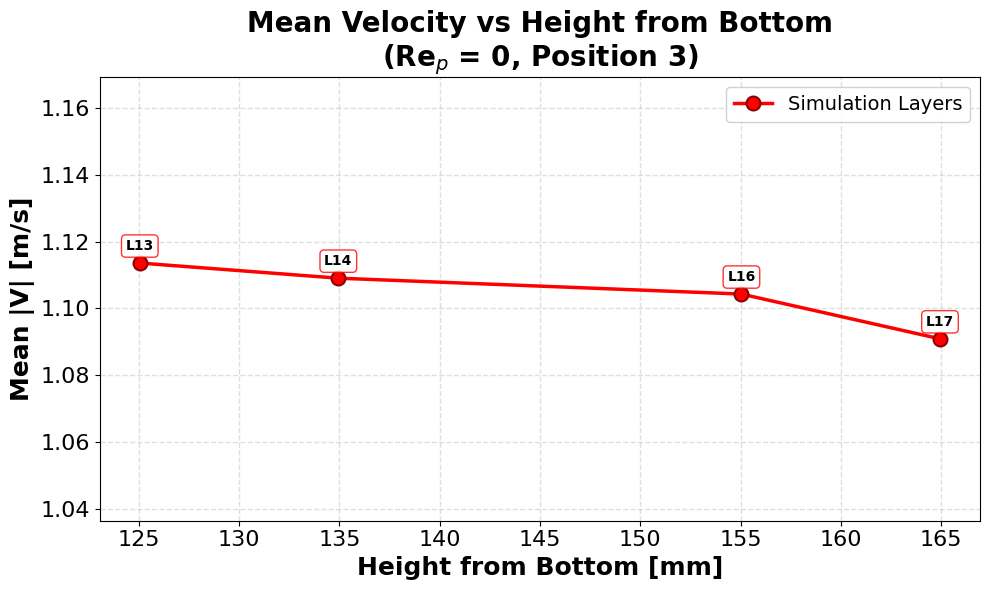

In [68]:
# Mean velocity vs height from bottom
sim_heights_m = []
sim_mean_vels = []
sim_layer_labels = []
for i, df_sim in enumerate(sim_dataframes):
    # Extract layer label
    sim_match = re.search(r'L(\d{2})', sim_file_names[i])
    layer_label = f"L{sim_match.group(1)}" if sim_match else f"Layer {i+1}"
    
    # Calculate average height (Z) for the layer
    avg_height = df_sim[sim_z_col].mean()
    sim_heights_m.append(avg_height)
    
    # Mean velocity magnitude for the layer
    mean_vel = df_sim['vel_magnitude'].mean()
    sim_mean_vels.append(mean_vel)
    
    sim_layer_labels.append(layer_label)

sim_heights_mm = np.array(sim_heights_m) * 1000

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sim_heights_mm, sim_mean_vels, 'ro-', label='Simulation Layers',
        linewidth=2.5, markersize=10, markeredgecolor='darkred', markeredgewidth=1.5)

# Add layer labels
for i, (height, vel, label) in enumerate(zip(sim_heights_mm, sim_mean_vels, sim_layer_labels)):
    ax.annotate(label, xy=(height, vel), xytext=(height, vel+0.003),
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='red', alpha=0.8),
                ha='center', va='bottom')
ax.set_ylim(min(sim_mean_vels)*0.95, max(sim_mean_vels)*1.05)
ax.set_xlabel('Height from Bottom [mm]', fontsize=18, fontweight='bold')
ax.set_ylabel('Mean |V| [m/s]', fontsize=18, fontweight='bold')
ax.set_title(f'Mean Velocity vs Height from Bottom\n(Re$_p$ = {Re_p}, Position {position})',
             fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.4, linestyle='--', linewidth=1)
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=14, loc='best', framealpha=0.9)
plt.tight_layout()
plt.savefig(f'{output_dir}/Mean_Velocity_vs_Height_Pos{position}_Re{Re_p}.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_726054/2912800852.py:4: UserWarning: Adding colorbar to a different Figure <Figure size 900x800 with 5 Axes> than <Figure size 200x600 with 1 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(contour_sim, cax=cax, orientation='vertical')


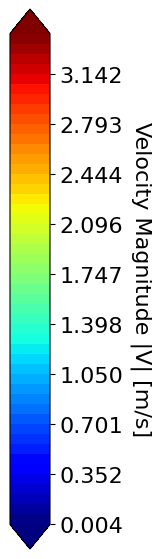

In [69]:
# Plot only vertical colorbar (uses existing `contour_sim`, `common_vmin`, `common_vmax`, `output_dir`, `position`, `Re_p`)
fig = plt.figure(figsize=(2, 6))
cax = fig.add_axes([0.18, 0.05, 0.2, 0.9]) #(left, bottom, width, height)
cbar = fig.colorbar(contour_sim, cax=cax, orientation='vertical')
cbar.set_label('Velocity Magnitude |V| [m/s]', rotation=270, labelpad=20, fontsize=16)
cbar.ax.tick_params(labelsize=16)
plt.savefig(f'{output_dir}/Colorbar_vertical_Pos{position}_Re{Re_p}.png', dpi=300, bbox_inches='tight')
plt.show()

FOR WATER

In [70]:
#Particle Reynolds number: 𝑅𝑒𝑝=𝜌*𝑣_𝑖𝑛𝑡*𝑑𝑝/𝜇
#For the same Reₚ and same dₚ, we must enforce:𝜌_air*𝑣_air/𝜇_air = 𝜌_water*𝑣_water/𝜇_water
#Fluid properties
#Air (20°C): ρ_air = 1.204 kg/m³ ; μ_air = 1.822×10⁻⁵ kg/(m·s)
#Water (20°C): ρ_water = 998 kg/m³ ; μ_water = 1.0×10⁻³ kg/(m·s)

rho_air = 1.204  # kg/m³
mu_air = 1.822e-5  # kg/(m·s)
rho_water = 998  # kg/m³
mu_water = 1.0e-3  # kg/(m·s)
v_air = 1.0  # m/s (example velocity in air)
# Calculate the equivalent velocity in water
v_water_factor = v_air * (rho_air * mu_water) / (rho_water * mu_air)
print(f"To achieve the same particle Reynolds number, the velocity in water should be multiplied by: {v_water_factor:.6f} m/s")

To achieve the same particle Reynolds number, the velocity in water should be multiplied by: 0.066214 m/s


In [71]:
# # Scale simulation velocities to equivalent water velocities and plot simulation layers
# sim_water_dfs = [df.copy() for df in sim_dataframes]

# # Scale velocities and recompute magnitude
# for df in sim_water_dfs:
#     df[sim_u_col] = df[sim_u_col] * v_water_factor
#     df[sim_w_col] = df[sim_w_col] * v_water_factor
#     df['vel_magnitude_water'] = np.sqrt(df[sim_u_col]**2 + df[sim_w_col]**2)

# # Determine common color scale for scaled simulation data
# all_sim_water_mag = np.hstack([df['vel_magnitude_water'].values for df in sim_water_dfs])
# all_sim_water_mag = all_sim_water_mag[np.isfinite(all_sim_water_mag)]
# vmin_water, vmax_water = all_sim_water_mag.min(), all_sim_water_mag.max()
# levels_water = np.linspace(vmin_water, vmax_water, 50)

# print(f"\nWater simulation velocity range:")
# print(f"  Min: {vmin_water:.6f} m/s")
# print(f"  Max: {vmax_water:.6f} m/s")

# n_layers = len(sim_water_dfs)
# fig, axes = plt.subplots(n_layers, 1, figsize=(12, 2.5 * n_layers))
# if n_layers == 1:
#     axes = [axes]

# # global x-limits for alignment
# x_min_global = min(df[sim_x_col].min() for df in sim_water_dfs)
# x_max_global = max(df[sim_x_col].max() for df in sim_water_dfs)

# for i, df in enumerate(sim_water_dfs):
#     ax = axes[i]
#     x = df[sim_x_col].values
#     z = df[sim_z_col].values
#     u = df[sim_u_col].values
#     w = df[sim_w_col].values
#     mag = df['vel_magnitude_water'].values

#     xi = np.linspace(x_min_global, x_max_global, n_grid)
#     zi = np.linspace(z.min(), z.max(), n_grid)
#     Xi, Zi = np.meshgrid(xi, zi)

#     points = np.column_stack((x, z))
#     Ui = griddata(points, u, (Xi, Zi), method='linear', fill_value=0)
#     Wi = griddata(points, w, (Xi, Zi), method='linear', fill_value=0)
#     Vmag = griddata(points, mag, (Xi, Zi), method='linear', fill_value=0)

#     # normalize for streamplot
#     speed = np.sqrt(Ui**2 + Wi**2)
#     Ui_n = np.zeros_like(Ui); Wi_n = np.zeros_like(Wi)
#     mask = speed > 1e-6
#     Ui_n[mask] = Ui[mask] / speed[mask]
#     Wi_n[mask] = Wi[mask] / speed[mask]

#     cf = ax.contourf(Xi, Zi, Vmag, levels=levels_water, cmap='jet', 
#                      vmin=vmin_water, vmax=vmax_water, extend='both')
#     ax.streamplot(Xi, Zi, Ui_n, Wi_n, density=1.2, color='white', 
#                   linewidth=1.1, arrowsize=1.0, arrowstyle='fancy')

#     # Extract layer label
#     sim_match = re.search(r'L(\d{2})', sim_file_names[i])
#     layer_label = f"L{sim_match.group(1)}" if sim_match else f"Layer {i+1}"

#     ax.annotate(layer_label, xy=(0.02, 0.50), xycoords='axes fraction',
#                 fontsize=14, fontweight='bold', 
#                 bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", alpha=0.8))

#     # Set exact limits to remove extra space
#     ax.set_ylim(z.min(), z.max())
#     ax.set_xlim(x_min_global, x_max_global)
#     ax.margins(x=0, y=0)
    
#     ax.grid(True, linestyle='--', alpha=0.15, color='white', linewidth=0.5)
    
#     # Only bottom subplot gets x ticks/labels
#     if i == n_layers - 1:
#         ax.tick_params(axis='x', bottom=True, labelbottom=True, labelsize=18)
#         ax.set_xlabel('Projected X-position [m]', fontsize=18, fontweight='bold')
#     else:
#         ax.tick_params(axis='x', bottom=False, labelbottom=False)
    
#     ax.tick_params(axis='y', left=True, labelleft=True, labelsize=18)

# # Y label on middle plot
# mid_idx = n_layers // 2
# axes[mid_idx].set_ylabel('Z-position [m]', fontsize=18, fontweight='bold')

# # Layout - NO VERTICAL GAPS for continuous appearance
# fig.subplots_adjust(
#     right=0.88,
#     top=0.96,
#     hspace=0.0,  # No vertical space between subplots
#     wspace=0.0
# )

# # Colorbar
# cbar_ax = fig.add_axes([0.90, 0.12, 0.04, 0.76]) # (left, bottom, width, height)
# cbar = fig.colorbar(cf, cax=cbar_ax)
# cbar.set_label(
#     'Velocity Magnitude |V| in Water [m/s]',
#     rotation=270,
#     labelpad=22,
#     fontsize=18, fontweight='bold'
# )
# cbar.ax.tick_params(labelsize=18)

# # Title
# fig.suptitle(
#     f'Water Simulaation Velocity FieldsRe$_p$ = {Re_p}, Position {position}',
#     fontsize=16, fontweight='bold', y=0.995
# )

# #plt.savefig(f'{output_dir}/Water_Parallel_Sim_Velocity_Fields_Pos{position}_Re{Re_p}.png', 
#  #           dpi=300, bbox_inches='tight')
# #print(f"\nSaved: {output_dir}/Water_Parallel_Sim_Velocity_Fields_Pos{position}_Re{Re_p}.png")
# #plt.show()

In [72]:
# # ============================================================================
# # COMPREHENSIVE WATER SIMULATION SUMMARY
# # ============================================================================

# print("="*80)
# print("WATER SIMULATION ANALYSIS")
# print("="*80)
# print(f"\nScaling Factor: Air → Water = {v_water_factor:.6f}")
# print(f"  This maintains constant particle Reynolds number (Re_p = {Re_p})")
# print(f"  ρ_air·v_air/μ_air = ρ_water·v_water/μ_water")

# # Calculate mean velocities per layer for water
# print("\n" + "="*80)
# print("SUMMARY: Mean Velocity Magnitude Per Layer (WATER)")
# print("="*80)

# layer_names_water = []
# layer_mean_vel_water = []
# layer_mean_u_water = []
# layer_mean_w_water = []

# for i in range(len(sim_water_dfs)):
#     df = sim_water_dfs[i]
    
#     # Extract layer label
#     sim_match = re.search(r'L(\d{2})', sim_file_names[i])
#     layer_name = f"L{sim_match.group(1)}" if sim_match else f"Layer {i+1}"
    
#     layer_names_water.append(layer_name)
#     layer_mean_vel_water.append(df['vel_magnitude_water'].mean())
#     layer_mean_u_water.append(df[sim_u_col].mean())
#     layer_mean_w_water.append(df[sim_w_col].mean())

# # Create summary DataFrame for water
# summary_df_water = pd.DataFrame({
#     'Layer': layer_names_water,
#     'Mean_|V|_[m/s]': layer_mean_vel_water,
#     'Mean_u_[m/s]': layer_mean_u_water,
#     'Mean_w_[m/s]': layer_mean_w_water
# })

# pd.options.display.float_format = '{:.6f}'.format
# print("\n" + summary_df_water.to_string(index=False))

# # Calculate statistics
# avg_mean_vel_water = summary_df_water['Mean_|V|_[m/s]'].mean()
# std_mean_vel_water = summary_df_water['Mean_|V|_[m/s]'].std()

# print(f"\nAverage Mean Velocity (Water) [m/s]: {avg_mean_vel_water:.6f}")
# print(f"Standard Deviation [m/s]: {std_mean_vel_water:.6f}")

# # Overall statistics for water
# print("\n" + "="*80)
# print("OVERALL WATER SIMULATION STATISTICS")
# print("="*80)

# all_water_u = []
# all_water_w = []
# all_water_mag = []

# for df in sim_water_dfs:
#     all_water_u.extend(df[sim_u_col].values)
#     all_water_w.extend(df[sim_w_col].values)
#     all_water_mag.extend(df['vel_magnitude_water'].values)

# all_water_u = np.array(all_water_u)
# all_water_w = np.array(all_water_w)
# all_water_mag = np.array(all_water_mag)

# stats_df_water = pd.DataFrame({
#     'Component': ['u (X-velocity)', 'w (Z-velocity)', '|V| (Magnitude)'],
#     'Min [m/s]': [all_water_u.min(), all_water_w.min(), all_water_mag.min()],
#     'Mean [m/s]': [all_water_u.mean(), all_water_w.mean(), all_water_mag.mean()],
#     'Max [m/s]': [all_water_u.max(), all_water_w.max(), all_water_mag.max()],
#     'Std Dev [m/s]': [all_water_u.std(), all_water_w.std(), all_water_mag.std()]
# })

# print("\n" + stats_df_water.to_string(index=False))

# # Save combined water summary to CSV
# combined_path_water = f'{output_dir}/water_simulation_summary_Pos{position}_Re{Re_p}.csv'

# with open(combined_path_water, 'w') as f:
#     f.write(f"# WATER SIMULATION SUMMARY (Re_p = {Re_p}, Position {position})\n")
#     f.write(f"# Scaling Factor (Air to Water): {v_water_factor:.6f}\n")
#     f.write(f"# Air properties: rho={rho_air} kg/m³, mu={mu_air} kg/(m·s)\n")
#     f.write(f"# Water properties: rho={rho_water} kg/m³, mu={mu_water} kg/(m·s)\n\n")
#     f.write("=== MEAN VELOCITY PER LAYER (WATER) ===\n")
#     summary_df_water.to_csv(f, index=False)
#     f.write("\n=== OVERALL WATER SIMULATION STATISTICS ===\n")
#     stats_df_water.to_csv(f, index=False)

# print(f"\n\nSaved water simulation summary to: {combined_path_water}")

# # ============================================================================
# # PLOT: Mean Velocity vs Height for Water Simulation
# # ============================================================================

# sim_heights_m_water = []
# sim_mean_vels_water = []
# sim_layer_labels_water = []

# for i, df in enumerate(sim_water_dfs):
#     # Extract layer label
#     sim_match = re.search(r'L(\d{2})', sim_file_names[i])
#     layer_label = f"L{sim_match.group(1)}" if sim_match else f"Layer {i+1}"
    
#     # Calculate average height (Z) for the layer
#     avg_height = df[sim_z_col].mean()
#     sim_heights_m_water.append(avg_height)
    
#     # Mean velocity magnitude for the layer (water)
#     mean_vel = df['vel_magnitude_water'].mean()
#     sim_mean_vels_water.append(mean_vel)
    
#     sim_layer_labels_water.append(layer_label)

# sim_heights_mm_water = np.array(sim_heights_m_water) * 1000

# # Create plot
# fig, ax = plt.subplots(figsize=(10, 6))

# ax.plot(sim_heights_mm_water, sim_mean_vels_water, 'bo-', label='Water Simulation Layers',
#         linewidth=2.5, markersize=10, markeredgecolor='darkblue', markeredgewidth=1.5)

# # Add layer labels
# for i, (height, vel, label) in enumerate(zip(sim_heights_mm_water, sim_mean_vels_water, sim_layer_labels_water)):
#     ax.annotate(label, xy=(height, vel), xytext=(height, vel+0.0002),
#                 fontsize=10, fontweight='bold',
#                 bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='blue', alpha=0.8),
#                 ha='center', va='bottom')

# ax.set_ylim(min(sim_mean_vels_water)*0.95, max(sim_mean_vels_water)*1.05)
# ax.set_xlabel('Height from Bottom [mm]', fontsize=18, fontweight='bold')
# ax.set_ylabel('Mean |V| in Water [m/s]', fontsize=18, fontweight='bold')
# ax.set_title(f'Mean Velocity vs Height from Bottom (Water Simulation)\n(Re$_p$ = {Re_p}, Position {position})',
#              fontsize=20, fontweight='bold')
# ax.grid(True, alpha=0.4, linestyle='--', linewidth=1)
# ax.tick_params(axis='both', labelsize=16)
# ax.legend(fontsize=14, loc='best', framealpha=0.9)

# # # Add text box with scaling info
# # textstr = f'Scaling Factor: {v_water_factor:.6f}\n(Air → Water for same Re$_p$)'
# # props = dict(boxstyle='round', facecolor='lightblue', alpha=0.7)
# # ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=12,
# #         verticalalignment='top', bbox=props)

# plt.tight_layout()
# plt.savefig(f'{output_dir}/Water_Mean_Velocity_vs_Height_Pos{position}_Re{Re_p}.png', 
#             dpi=300, bbox_inches='tight')
# print(f"Saved plot: {output_dir}/Water_Mean_Velocity_vs_Height_Pos{position}_Re{Re_p}.png")
# plt.show()

# # ============================================================================
# # COMPARISON: Air vs Water
# # ============================================================================

# print("\n" + "="*80)
# print("COMPARISON: AIR vs WATER SIMULATION")
# print("="*80)

# comparison_df = pd.DataFrame({
#     'Layer': layer_names_water,
#     'Mean_|V|_Air_[m/s]': layer_mean_vel_sim,
#     'Mean_|V|_Water_[m/s]': layer_mean_vel_water,
#     'Ratio_Air/Water': np.array(layer_mean_vel_sim) / np.array(layer_mean_vel_water)
# })

# print("\n" + comparison_df.to_string(index=False))
# print(f"\nAverage Velocity Ratio (Air/Water): {comparison_df['Ratio_Air/Water'].mean():.2f}")
# print(f"Expected Ratio: {1/v_water_factor:.2f}")
# print(f"Difference: {abs(comparison_df['Ratio_Air/Water'].mean() - 1/v_water_factor):.4f}")

# # Save comparison
# comparison_path = f'{output_dir}/air_water_comparison_Pos{position}_Re{Re_p}.csv'
# comparison_df.to_csv(comparison_path, index=False)
# print(f"\nSaved comparison to: {comparison_path}")

# pd.reset_option('display.float_format')

# print("\n" + "="*80)
# print("WATER SIMULATION ANALYSIS COMPLETE")
# print("="*80)